In [195]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [196]:
import pandas as pd

# Lendo o CSV
df = pd.read_csv("acidentes.csv", encoding="utf-8")

# Visualizar as primeiras linhas
df.head()



,compriment,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry,trecho_id,qtd_acidentes
0,4070.683523,4208203,Itajaí,420020.0,Itajaí,4207.0,Blumenau,42,Santa Catarina,SC,4,Sul,S,4208203.0,Itajaí - Balneário Camboriú/SC,289.215,LINESTRING (727038.5504163788 7021672.27435838...,0,0
1,2885.021693,4208203,Itajaí,420020.0,Itajaí,4207.0,Blumenau,42,Santa Catarina,SC,4,Sul,S,4208203.0,Itajaí - Balneário Camboriú/SC,289.215,LINESTRING (729764.4337103107 7023855.78655302...,1,0
2,6719.245321,4208203,Itajaí,420020.0,Itajaí,4207.0,Blumenau,42,Santa Catarina,SC,4,Sul,S,4208203.0,Itajaí - Balneário Camboriú/SC,289.215,LINESTRING (726596.6579196572 7028757.97377213...,2,127
3,3793.880959,4208203,Itajaí,420020.0,Itajaí,4207.0,Blumenau,42,Santa Catarina,SC,4,Sul,S,4208203.0,Itajaí - Balneário Camboriú/SC,289.215,LINESTRING (726318.1829404269 7023712.19877292...,3,113
4,2725.480633,4208203,Itajaí,420020.0,Itajaí,4207.0,Blumenau,42,Santa Catarina,SC,4,Sul,S,4208203.0,Itajaí - Balneário Camboriú/SC,289.215,LINESTRING (727440.0115479529 7020536.26540563...,4,68


In [197]:
df["SIGLA_UF"].value_counts()

SIGLA_UF
RS    1001
PR     919
SC     553
Name: count, dtype: int64

In [198]:
# Criar feature densidade (acidentes por km do trecho)
df["densidade"] = df["qtd_acidentes"] / df["compriment"].replace(0, np.nan)

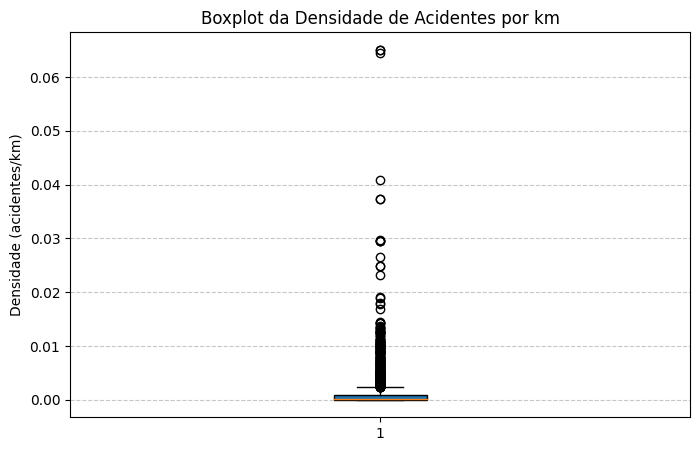

In [199]:
import matplotlib.pyplot as plt

# Boxplot da densidade
plt.figure(figsize=(8,5))
plt.boxplot(df["densidade"].dropna(), vert=True, patch_artist=True)
plt.title("Boxplot da Densidade de Acidentes por km")
plt.ylabel("Densidade (acidentes/km)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [200]:
# Calcular quartis
quartis = df["densidade"].quantile([0.25, 0.5, 0.75])
Q1, Q2, Q3 = quartis[0.25], quartis[0.5], quartis[0.75]

# Função para categorizar risco
def categorizar_por_quartil(x):
    if x <= Q1: #menor que 0.25
        return "baixo"
    elif Q1 < x <= Q2: # entre 0.25 e 0.5
        return "medio"
    elif Q2 < x <= Q3: # entre 0.5 e 0.75
        return "alto"
    elif x > Q3: # maior que 0.75
        return "muito alto"

In [201]:
# Criar nova coluna
df["risco_quartil"] = df["densidade"].apply(categorizar_por_quartil)

# Ver contagem por categoria
print(df["risco_quartil"].value_counts())

risco_quartil
baixo         940
muito alto    618
alto          618
medio         297
Name: count, dtype: int64


In [202]:
df.shape

(2473, 21)

In [203]:
df["SIGLA_UF"].value_counts()

SIGLA_UF
RS    1001
PR     919
SC     553
Name: count, dtype: int64

In [204]:
# Features para o modelo
features = ["compriment", "qtd_acidentes", "SIGLA_UF"]
X = df[features]
y = df["risco_quartil"]

In [205]:
# One-hot encoding
X = pd.get_dummies(X, columns=["SIGLA_UF"], drop_first=True)

In [206]:
X.head()

,compriment,qtd_acidentes,SIGLA_UF_RS,SIGLA_UF_SC
0,4070.683523,0,False,True
1,2885.021693,0,False,True
2,6719.245321,127,False,True
3,3793.880959,113,False,True
4,2725.480633,68,False,True


In [207]:
# Normalizar numéricos
scaler = StandardScaler()
num_cols = ["compriment", "qtd_acidentes"]
X[num_cols] = scaler.fit_transform(X[num_cols])

In [208]:
# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Treinar modelo
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [209]:
# Previsões
y_pred = clf.predict(X_test)

# Relatório de desempenho
report_dens = classification_report(y_test, y_pred, output_dict=True)
conf_matrix_dens = confusion_matrix(y_test, y_pred)

conf_matrix_dens

array([[182,   0,   2,   2],
       [  0, 282,   0,   0],
       [  2,   0,  87,   0],
       [  5,   0,   0, 180]], dtype=int64)

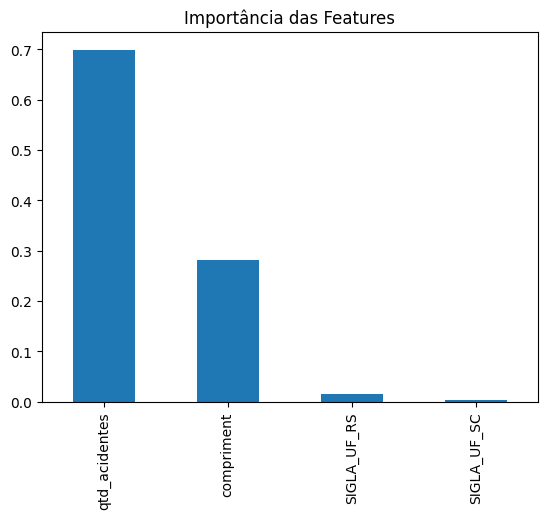

In [210]:
feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title("Importância das Features")
plt.show()